In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import swin_t, Swin_T_Weights
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import os
import random
import shutil

random.seed(42)

def get_slide_list(root_dir, cls):
    cls_dir = os.path.join(root_dir, cls)
    return [
        s for s in os.listdir(cls_dir)
        if os.path.isdir(os.path.join(cls_dir, s))
    ]

# Get slides
hcc_train_slides = get_slide_list("TRAIN", "hcc")
chol_train_slides = get_slide_list("TRAIN", "chol")

print("Total HCC:", len(hcc_train_slides))
print("Total CHOL:", len(chol_train_slides))

# Select 28 HCC randomly
selected_hcc = random.sample(hcc_train_slides, 28)
selected_chol = chol_train_slides  # 28


Total HCC: 54
Total CHOL: 28


In [3]:
MODEL_B_TRAIN = "MODEL_B/train"
MODEL_B_TEST  = "MODEL_B/test"

os.makedirs(MODEL_B_TRAIN, exist_ok=True)
os.makedirs(MODEL_B_TEST, exist_ok=True)


In [4]:
from torch.utils.data import Dataset
from PIL import Image

class ModelBPatchDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        self.label_map = {
            "hcc": 0,
            "chol": 1
        }

        for cls in ["hcc", "chol"]:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.exists(cls_dir):
                continue

            for slide_id in os.listdir(cls_dir):
                slide_path = os.path.join(cls_dir, slide_id)

                if not os.path.isdir(slide_path):
                    continue

                for fname in os.listdir(slide_path):
                    if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                        self.samples.append(
                            (os.path.join(slide_path, fname),
                             self.label_map[cls])
                        )

        print(f"Loaded {len(self.samples)} patches from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)


In [5]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [9]:
from torch.utils.data import DataLoader

train_dataset = ModelBPatchDataset(MODEL_B_TRAIN, transform=train_transform)
test_dataset  = ModelBPatchDataset(MODEL_B_TEST, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)


Loaded 38500 patches from MODEL_B/train
Loaded 21000 patches from MODEL_B/test


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [11]:
from torchvision.models import swin_t, Swin_T_Weights
import torch.nn as nn

modelB = swin_t(weights=Swin_T_Weights.DEFAULT)
modelB.head = nn.Linear(modelB.head.in_features, 2)

modelB = modelB.to(device)


/home/jupyter-238w1a05a8/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(modelB.parameters(), lr=1e-4)


In [13]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


In [14]:
EPOCHS = 15

for epoch in range(EPOCHS):
    loss, acc = train_epoch(modelB, train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")


Epoch 1/15 | Loss: 0.3162 | Train Acc: 0.8537
Epoch 2/15 | Loss: 0.1375 | Train Acc: 0.9459
Epoch 3/15 | Loss: 0.0957 | Train Acc: 0.9633
Epoch 4/15 | Loss: 0.0755 | Train Acc: 0.9718
Epoch 5/15 | Loss: 0.0681 | Train Acc: 0.9749
Epoch 6/15 | Loss: 0.0602 | Train Acc: 0.9786
Epoch 7/15 | Loss: 0.0523 | Train Acc: 0.9800
Epoch 8/15 | Loss: 0.0489 | Train Acc: 0.9831
Epoch 9/15 | Loss: 0.0495 | Train Acc: 0.9820
Epoch 10/15 | Loss: 0.0404 | Train Acc: 0.9856
Epoch 11/15 | Loss: 0.0422 | Train Acc: 0.9842
Epoch 12/15 | Loss: 0.0370 | Train Acc: 0.9867
Epoch 13/15 | Loss: 0.0349 | Train Acc: 0.9874
Epoch 14/15 | Loss: 0.0341 | Train Acc: 0.9873
Epoch 15/15 | Loss: 0.0315 | Train Acc: 0.9888


In [15]:
def evaluate(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


In [16]:
y_true, y_pred = evaluate(modelB, test_loader)

print("Patch-Level Test Accuracy:",
      accuracy_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)

print(classification_report(
    y_true, y_pred,
    target_names=["HCC", "CHOL"],
    digits=4
))


Patch-Level Test Accuracy: 0.8938095238095238
[[10404  1496]
 [  734  8366]]
              precision    recall  f1-score   support

         HCC     0.9341    0.8743    0.9032     11900
        CHOL     0.8483    0.9193    0.8824      9100

    accuracy                         0.8938     21000
   macro avg     0.8912    0.8968    0.8928     21000
weighted avg     0.8969    0.8938    0.8942     21000



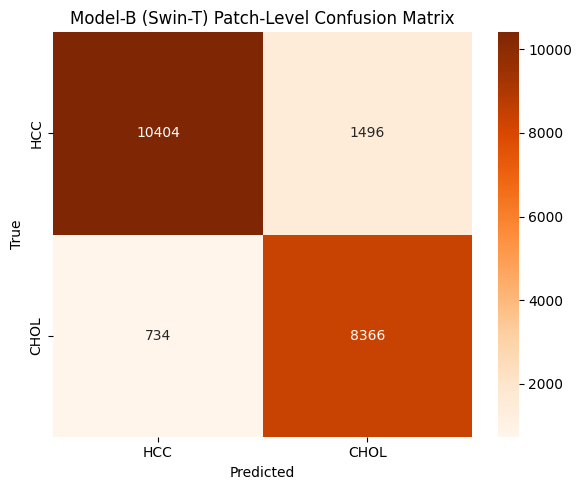

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["HCC", "CHOL"],
    yticklabels=["HCC", "CHOL"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Model-B (Swin-T) Patch-Level Confusion Matrix")
plt.tight_layout()
plt.show()


In [18]:
import torch.nn.functional as F
import numpy as np
import os
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [19]:
def evaluate_slide_level_modelB(model, root_dir, transform, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for cls in ["hcc", "chol"]:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.exists(cls_dir):
                continue

            for slide_id in os.listdir(cls_dir):
                slide_path = os.path.join(cls_dir, slide_id)

                patch_probs = []

                for fname in os.listdir(slide_path):
                    if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                        continue

                    img = Image.open(os.path.join(slide_path, fname)).convert("RGB")
                    img = transform(img).unsqueeze(0).to(device)

                    output = model(img)
                    prob = F.softmax(output, dim=1)[0][1].item()  # chol prob
                    patch_probs.append(prob)

                if len(patch_probs) == 0:
                    continue

                avg_prob = np.mean(patch_probs)

                true_label = 0 if cls == "hcc" else 1
                pred_label = 1 if avg_prob > 0.5 else 0

                y_true.append(true_label)
                y_pred.append(pred_label)

    return y_true, y_pred


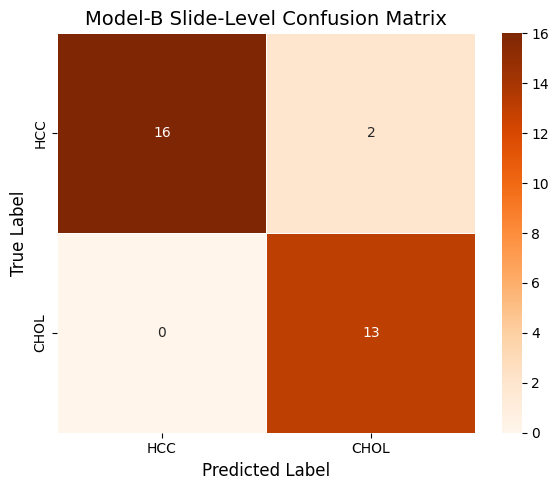

In [21]:
cm_B = confusion_matrix(y_true_B, y_pred_B)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_B,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["HCC", "CHOL"],
    yticklabels=["HCC", "CHOL"],
    linewidths=0.5
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Model-B Slide-Level Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()


In [23]:
torch.save(modelB.state_dict(), "model_B1_final_patch_swin-1.pth")
print("Model-B (patch CNN) saved successfully.")


Model-B (patch CNN) saved successfully.


In [25]:
import numpy as np
from sklearn.metrics import accuracy_score

def accuracy_confidence_interval(y_true, y_pred, confidence=0.95):
    acc = accuracy_score(y_true, y_pred)
    n = len(y_true)

    z = 1.96  # for 95%
    se = np.sqrt((acc * (1 - acc)) / n)

    lower = acc - z * se
    upper = acc + z * se

    return acc, lower, upper


In [26]:
acc, low, high = accuracy_confidence_interval(y_true_B, y_pred_B)

print(f"Model-B Accuracy: {acc:.4f}")
print(f"95% CI: [{low:.4f}, {high:.4f}]")


Model-B Accuracy: 0.9355
95% CI: [0.8490, 1.0220]


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

def print_metrics(y_true, y_pred, name):
    print(f"\n{name} Metrics")
    print("Precision:", precision_score(y_true, y_pred, average="weighted"))
    print("Recall:", recall_score(y_true, y_pred, average="weighted"))
    print("F1 Score:", f1_score(y_true, y_pred, average="weighted"))


In [28]:
print_metrics(y_true_B, y_pred_B, "Model-B")


Model-B Metrics
Precision: 0.9440860215053763
Recall: 0.9354838709677419
F1 Score: 0.9358904852263487


In [30]:
from sklearn.utils import resample

def bootstrap_accuracy(y_true, y_pred, n_bootstrap=1000):

    scores = []

    for _ in range(n_bootstrap):
        y_t, y_p = resample(y_true, y_pred)
        scores.append(accuracy_score(y_t, y_p))

    scores = np.array(scores)

    mean = scores.mean()
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return mean, lower, upper



In [41]:
mean, low, high = bootstrap_accuracy(y_true_B, y_pred_B)
print("Model-B Bootstrap Accuracy:", mean)
print("95% CI:", low, high)


Model-B Bootstrap Accuracy: 0.8937937619047619
95% CI: 0.8896166666666667 0.8983345238095238


In [32]:
def evaluate_modelB_with_probs(modelB, loader, device):

    modelB.eval()
    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            outputs = modelB(imgs)
            probs = torch.softmax(outputs, dim=1)

            # CHOL probability
            chol_prob = probs[:,1].cpu().numpy()

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(chol_prob)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


In [33]:
y_true_B, y_pred_B, y_prob_B = evaluate_modelB_with_probs(
    modelB,
    test_loader,
    device
)


In [34]:
from sklearn.metrics import roc_auc_score

roc_auc_B = roc_auc_score(y_true_B, y_prob_B)
print("Model-B ROC-AUC:", roc_auc_B)

Model-B ROC-AUC: 0.962747926863053


In [38]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_true_B, y_pred_B)
print("Cohen Kappa Score:", kappa)


Cohen Kappa Score: 0.7858843711593609


In [35]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

def plot_roc_curve(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()


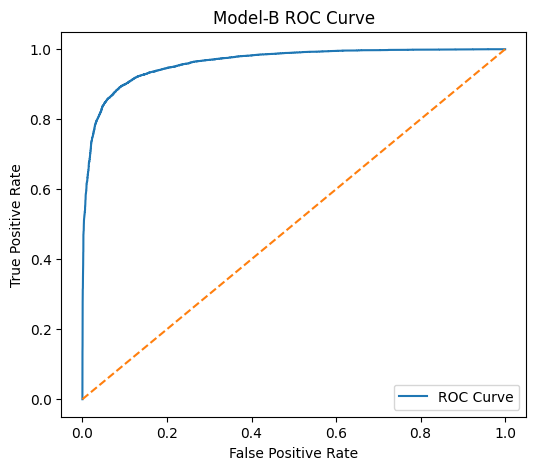

In [36]:
plot_roc_curve(y_true_B, y_prob_B, "Model-B ROC Curve")